Notebook to do a direct comparison between the PSF second moments published in the ConsDB vs the DRP to make sure they are not very divergent

In [1]:
from lsst.summit.utils import ConsDbClient

In [2]:
import numpy as np
from astropy.table import Table, join
from astropy.time import Time

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
%matplotlib widget

from lsst.meas.algorithms.installGaussianPsf import FwhmPerSigma

from tqdm.notebook import tqdm

In [3]:
os.environ["no_proxy"] += ",.consdb"

In [4]:
url="http://consdb-pq.consdb:8080/consdb"

In [5]:
consdb=ConsDbClient(url)

In [18]:
# Query the exposure consDB table only
exposure = consdb.query("SELECT * FROM cdb_lsstcomcam.exposure WHERE day_obs > 20241001")

In [19]:
exposure

exposure_id,exposure_name,controller,day_obs,seq_num,physical_filter,band,s_ra,s_dec,sky_rotation,azimuth_start,azimuth_end,azimuth,altitude_start,altitude_end,altitude,zenith_distance_start,zenith_distance_end,zenith_distance,airmass,exp_midpt,exp_midpt_mjd,obs_start,obs_start_mjd,obs_end,obs_end_mjd,exp_time,shut_time,dark_time,group_id,cur_index,max_index,img_type,emulated,science_program,observation_reason,target_name,air_temp,pressure,humidity,wind_speed,wind_dir,dimm_seeing,focus_z,simulated,s_region,vignette,vignette_min
int64,str20,str1,int64,int64,str7,str5,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,str26,float64,str26,float64,str26,float64,float64,float64,float64,str26,int64,int64,str9,bool,object,object,object,float64,float64,float64,float64,float64,object,object,object,object,str9,str9
2024102100004,CC_O_20241021_000004,O,20241021,4,r_03,r,281.10897697316676,-60.63258846588334,0.0,148.937084296875,148.937084296875,148.937084296875,90.0,90.0,90.0,-6.36110936292703e-15,-6.36110936292703e-15,-6.36110936292703e-15,None,2024-10-21T20:27:35.710000,60604.85249664272,2024-10-21T20:27:35.700000,60604.8524965299,2024-10-21T20:27:35.720000,60604.85249675554,0.0,0.0,0.019495487213134766,2024-10-21T20:27:35.569,1,1,BIAS,False,None,None,BLOCK-T193,13.324999809265137,74105.0,19.399999618530273,5.421000003814697,20.35474967956543,None,None,None,None,UNKNOWN,UNKNOWN
2024102100005,CC_O_20241021_000005,O,20241021,5,r_03,r,281.10897697316676,-60.63258846588334,0.0,148.937084296875,148.937084296875,148.937084296875,90.0,90.0,90.0,-6.36110936292703e-15,-6.36110936292703e-15,-6.36110936292703e-15,None,2024-10-21T20:28:44.304000,60604.85329055754,2024-10-21T20:28:44.294000,60604.85329043966,2024-10-21T20:28:44.314000,60604.85329067541,0.0,0.0,0.020368576049804688,2024-10-21T20:28:44.186,1,1,BIAS,False,None,None,BLOCK-T193,13.975000381469727,74105.0,17.950000762939453,5.087399959564209,15.984796524047852,None,None,None,None,UNKNOWN,UNKNOWN
2024102100006,CC_O_20241021_000006,O,20241021,6,r_03,r,281.10897697316676,-60.63258846588334,0.0,148.937084296875,148.937084296875,148.937084296875,90.0,90.0,90.0,-6.36110936292703e-15,-6.36110936292703e-15,-6.36110936292703e-15,None,2024-10-21T20:28:46.834000,60604.853319835966,2024-10-21T20:28:46.826000,60604.853319746086,2024-10-21T20:28:46.842000,60604.85331992585,0.0,0.0,0.015531778335571289,2024-10-21T20:28:44.186,1,1,BIAS,False,None,None,BLOCK-T193,13.949999809265137,74105.0,18.049999237060547,4.920599937438965,4.904906272888184,None,None,None,None,UNKNOWN,UNKNOWN
2024102100007,CC_O_20241021_000007,O,20241021,7,r_03,r,281.10897697316676,-60.63258846588334,0.0,148.937084296875,148.937084296875,148.937084296875,90.0,90.0,90.0,-6.36110936292703e-15,-6.36110936292703e-15,-6.36110936292703e-15,None,2024-10-21T20:28:49.367000,60604.85334915687,2024-10-21T20:28:49.358000,60604.85334904892,2024-10-21T20:28:49.376000,60604.853349264806,0.0,0.0,0.018652677536010742,2024-10-21T20:28:44.186,1,1,BIAS,False,None,None,BLOCK-T193,13.949999809265137,74105.0,18.049999237060547,4.586999893188477,5.005039215087891,None,None,None,None,UNKNOWN,UNKNOWN
2024102100008,CC_O_20241021_000008,O,20241021,8,r_03,r,281.10897697316676,-60.63258846588334,0.0,148.937084296875,148.937084296875,148.937084296875,90.0,90.0,90.0,-6.36110936292703e-15,-6.36110936292703e-15,-6.36110936292703e-15,None,2024-10-21T20:28:51.894500,60604.85337840978,2024-10-21T20:28:51.887000,60604.85337831847,2024-10-21T20:28:51.902000,60604.85337850109,0.0,0.0,0.015778541564941406,2024-10-21T20:28:44.186,1,1,BIAS,False,None,None,BLOCK-T193,13.925000190734863,74105.0,18.174999237060547,4.086599826812744,4.349503517150879,None,None,None,None,UNKNOWN,UNKNOWN
2024102100009,CC_O_20241021_000009,O,20241021,9,r_03,r,281.10897697316676,-60.63258846588334,0.0,148.937084296875,148.937084296875,148.937084296875,90.0,90.0,90.0,-6.36110936292703e-15,-6.36110936292703e-15,-6.36110936292703e-15,None,2024-10-21T20:28

In [20]:
# Load the CSV file into an Astropy Table
file_path = "ringss4rubin.csv"
ringss_data = Table.read(file_path, format="csv")

# Display table info to check structure
ringss_data.info()

<Table length=78041>
 name   dtype 
------ -------
  time   str19
  star   int64
   zen float64
  flux   int64
  see2 float64
   see float64
  fsee float64
  wind float64
  tau0 float64
theta0 float64
totvar float64
  erms float64
    J0 float64
  J025 float64
   J05 float64
    J1 float64
    J2 float64
    J4 float64
    J8 float64
   J16 float64


In [21]:
len(ringss_data)

78041

In [22]:
# Ensure time columns are Astropy Time objects
ringss_data["time"] = Time(ringss_data["time"])
exposure["exp_midpt"] = Time(exposure["exp_midpt"])

# Find the nearest neighbor index in 'table' for each entry in 'ringss_data'
idx = np.searchsorted(exposure["exp_midpt"].jd, ringss_data["time"].jd)

# Prevent out-of-bounds indices
idx = np.clip(idx, 0, len(exposure) - 1)

# Compute time differences (keeping TimeDelta)
time_diffs = exposure["exp_midpt"][idx] - ringss_data["time"]

# Extract seconds properly **before using NumPy operations**
time_diffs_sec = np.abs(time_diffs.sec)  # Now it's a NumPy array of seconds

# Define the max time difference threshold
max_diff = 30  # in seconds
mask = time_diffs_sec < max_diff  # Now this will work correctly

# Merge tables using the matched indices
merged_table = ringss_data[mask].copy()  # Copy only matched rows
for col in exposure.colnames:
    merged_table[col] = exposure[col][idx][mask]  # Copy matched columns

# Print merged table
print(merged_table)

          time          star  zen  ... vignette vignette_min
----------------------- ---- ----- ... -------- ------------
2024-10-22 01:04:20.000 8425 16.87 ...  UNKNOWN      UNKNOWN
2024-10-22 01:17:00.000 8425 17.47 ...  UNKNOWN      UNKNOWN
2024-10-22 01:17:33.000 8425 17.51 ...  UNKNOWN      UNKNOWN
2024-10-22 02:16:51.000 8425 23.78 ...  UNKNOWN      UNKNOWN
2024-10-22 02:22:46.000 8425  24.6 ...  UNKNOWN      UNKNOWN
2024-10-22 02:38:50.000  472 31.87 ...  UNKNOWN      UNKNOWN
2024-10-22 02:39:25.000  472 31.82 ...  UNKNOWN      UNKNOWN
2024-10-22 02:42:14.000  472 31.56 ...  UNKNOWN      UNKNOWN
2024-10-22 02:42:47.000  472 31.51 ...  UNKNOWN      UNKNOWN
2024-10-22 02:43:22.000  472 31.46 ...  UNKNOWN      UNKNOWN
                    ...  ...   ... ...      ...          ...
2024-12-12 08:20:05.000 2294 38.17 ...       NO           NO
2024-12-12 08:20:41.000 2294  38.3 ...       NO           NO
2024-12-12 08:21:14.000 2294 38.42 ...       NO           NO
2024-12-12 08:21:47.000 

In [11]:
merged_table.columns

<TableColumns names=('time','star','zen','flux','see2','see','fsee','wind','tau0','theta0','totvar','erms','J0','J025','J05','J1','J2','J4','J8','J16','exposure_id','exposure_name','controller','day_obs','seq_num','physical_filter','band','s_ra','s_dec','sky_rotation','azimuth_start','azimuth_end','azimuth','altitude_start','altitude_end','altitude','zenith_distance_start','zenith_distance_end','zenith_distance','airmass','exp_midpt','exp_midpt_mjd','obs_start','obs_start_mjd','obs_end','obs_end_mjd','exp_time','shut_time','dark_time','group_id','cur_index','max_index','img_type','emulated','science_program','observation_reason','target_name','air_temp','pressure','humidity','wind_speed','wind_dir','dimm_seeing','focus_z','simulated','s_region','vignette','vignette_min')>

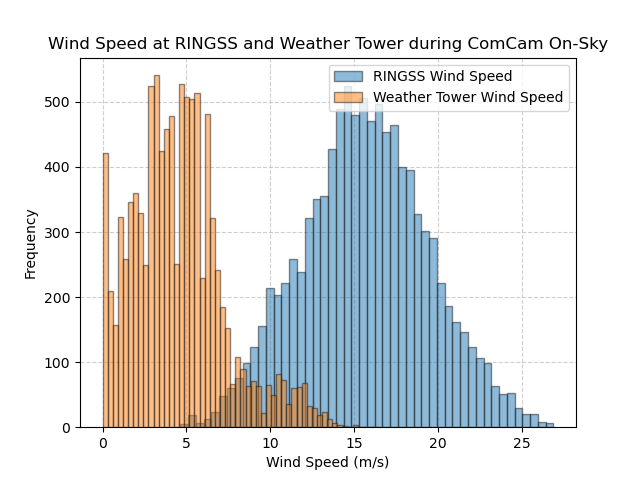

In [23]:
# Plot histogram using Freedman-Diaconis rule
plt.figure()
plt.xlabel('Wind Speed (m/s)')
plt.ylabel("Frequency")
plt.title(f"Wind Speed at RINGSS and Weather Tower during ComCam On-Sky")
plt.grid(True, linestyle="--", alpha=0.6, zorder=0)
plt.hist(merged_table["wind"], bins='fd', edgecolor='0.1', zorder=2,alpha=0.5, label='RINGSS Wind Speed')
plt.hist(merged_table["wind_speed"], bins="fd", edgecolor='0.1', zorder=3,alpha=0.5, label='Weather Tower Wind Speed')
plt.legend()
plt.show()

/tmp/ipykernel_705/2830166217.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


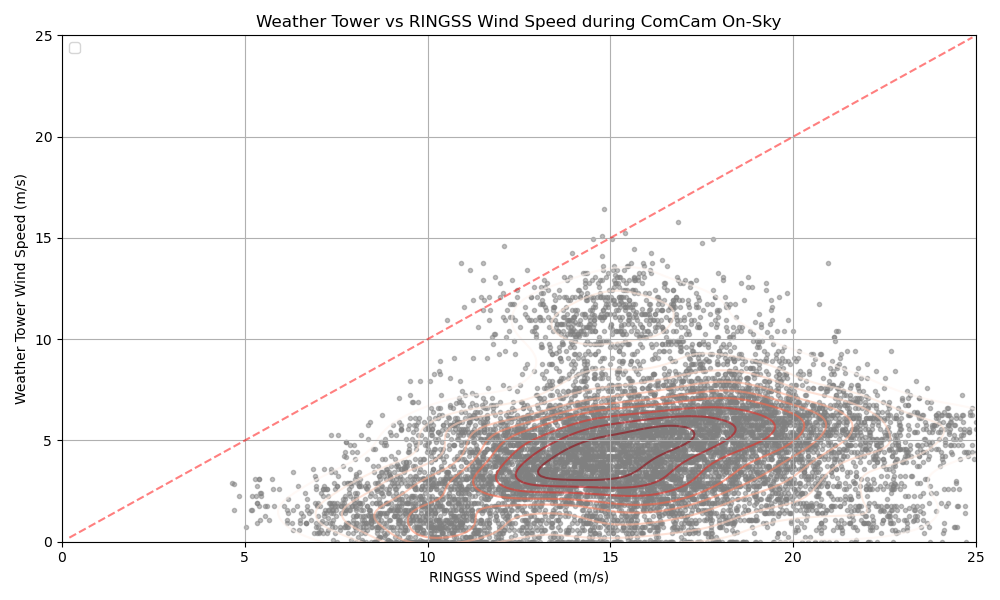

In [30]:
# Plot the time vs the specified column
plt.figure(figsize=(10, 6))
plt.plot(merged_table["wind"], merged_table["wind_speed"],'.', color='0.5',zorder=0, alpha=0.5)
sns.kdeplot(
    x=merged_table["wind"], 
    y=merged_table["wind_speed"], 
    levels=10,  # Number of contour levels
    cmap="Reds",  # Color map for contours
    alpha=0.6,
    zorder=1,
)

plt.plot(np.arange(0.2,25,0.1), np.arange(0.2,25,0.1), 'r--', alpha=0.5)
plt.xlim(0,25)
plt.ylim(0,25)
plt.ylabel('Weather Tower Wind Speed (m/s)')
plt.xlabel('RINGSS Wind Speed (m/s)')
plt.title(f"Weather Tower vs RINGSS Wind Speed during ComCam On-Sky")
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()

/tmp/ipykernel_705/3057382411.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


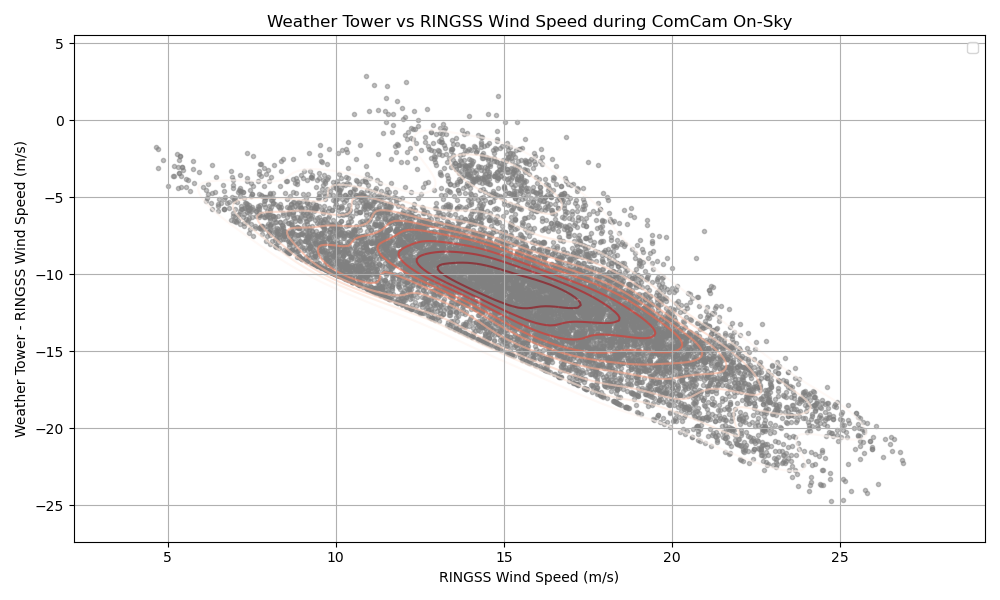

In [31]:
# Plot the time vs the specified column
plt.figure(figsize=(10, 6))
plt.plot(merged_table["wind"], merged_table["wind_speed"]-merged_table["wind"],'.', color='0.5',zorder=0, alpha=0.5)
sns.kdeplot(
    x=merged_table["wind"], 
    y=merged_table["wind_speed"]-merged_table["wind"], 
    levels=10,  # Number of contour levels
    cmap="Reds",  # Color map for contours
    alpha=0.6,
    zorder=1,
)

plt.ylabel('Weather Tower - RINGSS Wind Speed (m/s)')
plt.xlabel('RINGSS Wind Speed (m/s)')
plt.title(f"Weather Tower vs RINGSS Wind Speed during ComCam On-Sky")
plt.legend()
plt.grid(True)
plt.tight_layout()  # Adjust layout to prevent clipping of labels
plt.show()